# 交叉表规则生成

基于二维交叉表分析生成组合规则的 Python 实现，包含数据探索、变量分箱、透视表构建与规则制定。

In [123]:
import pandas as pd
import numpy as np
import scorecardpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings("ignore")

# 交叉表规则生成

基于二维交叉表分析生成组合规则的 Python 实现，包含数据探索、变量分箱、透视表构建与规则制定。

In [124]:
df = pd.read_csv('lending_club_sample.csv')
df.shape

(396030, 27)

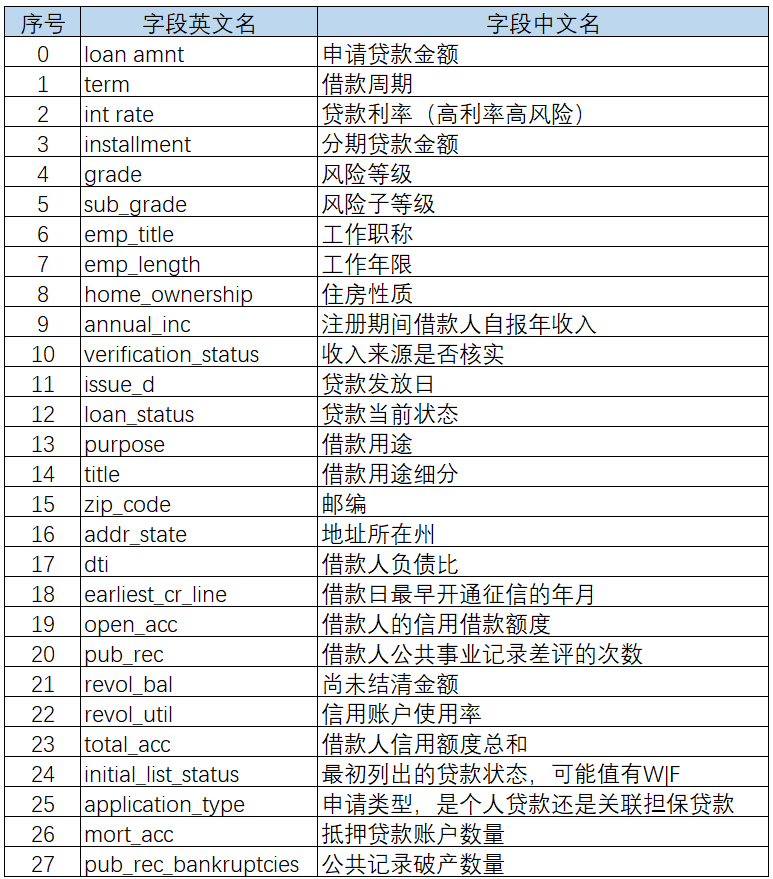

In [125]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [127]:
def simple_statics(df):
    # 读入数据
    stats = []
    for col in df.columns:
        stats.append((col, df[col].nunique(), 
                      (df[col].isnull()).sum() * 100 / df.shape[0],
                      df[col].value_counts(normalize=True, dropna=False).values[0] * 100, 
                      df[col].dtype))

    stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', 'Percentage_of_null',
                                            'Percentage_of_mode', 'Type'])
    stats_df.sort_values('Unique_values', ascending=False, inplace=True)
    return stats_df

In [128]:
sts_df = simple_statics(df)
sts_df.sort_values(by=['Percentage_of_null'],ascending=False)

,Feature,Unique_values,Percentage_of_null,Percentage_of_mode,Type
24,mort_acc,33,9.543469,35.294548,float64
6,emp_title,173105,5.789208,5.789208,object
7,emp_length,11,4.621115,31.826124,object
14,title,48816,0.443401,38.500114,object
25,pub_rec_bankruptcies,9,0.135091,88.473095,float64
20,revol_util,1226,0.069692,0.558796,float64
26,address,393700,0.000000,0.002020,object
12,loan_status,2,0.000000,80.387092,object
1,term,2,0.000000,76.258112,object
10,verification_status,3,0.000000,35.240512,object


## 1. 目标变量

<Axes: xlabel='loan_status'>

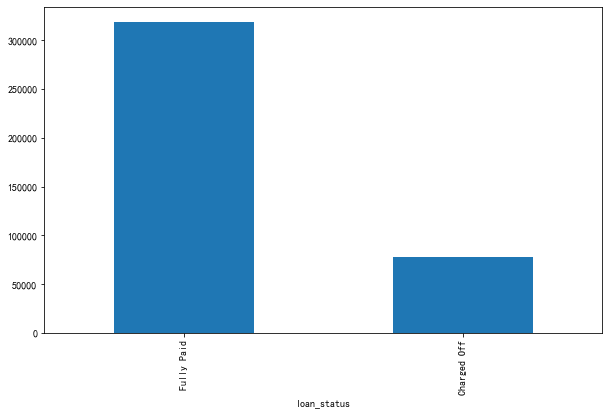

In [48]:
# 目标变量
yflag = 'loan_status'
plt.figure(figsize=(10,6))
df['loan_status'].value_counts(dropna=False).plot.bar()

In [129]:
df['loan_status'] = df['loan_status'].map({'Fully Paid':0,'Charged Off':1})
df['loan_status'].value_counts(dropna=False)

loan_status
0    318357
1     77673
Name: count, dtype: int64

## 2. 特征变量
### 2.1. 变量分类

In [130]:
col = df.columns.difference([yflag,'issue_d','address','emp_title','earliest_cr_line','title'])
# 筛选float和int的数值类型变量
num_list = df[col].select_dtypes(include=['float','int64']).columns.tolist()
# 筛选ojbect字符型的数值类型变量
obj_list = df[col].select_dtypes(include=['object']).columns.tolist()
print('数值类型变量共',len(num_list))
print('object类型变量共',len(obj_list))

数值类型变量共 12
object类型变量共 9


### 2.2. 离散性变量对目标变量坏账率的可视化分析

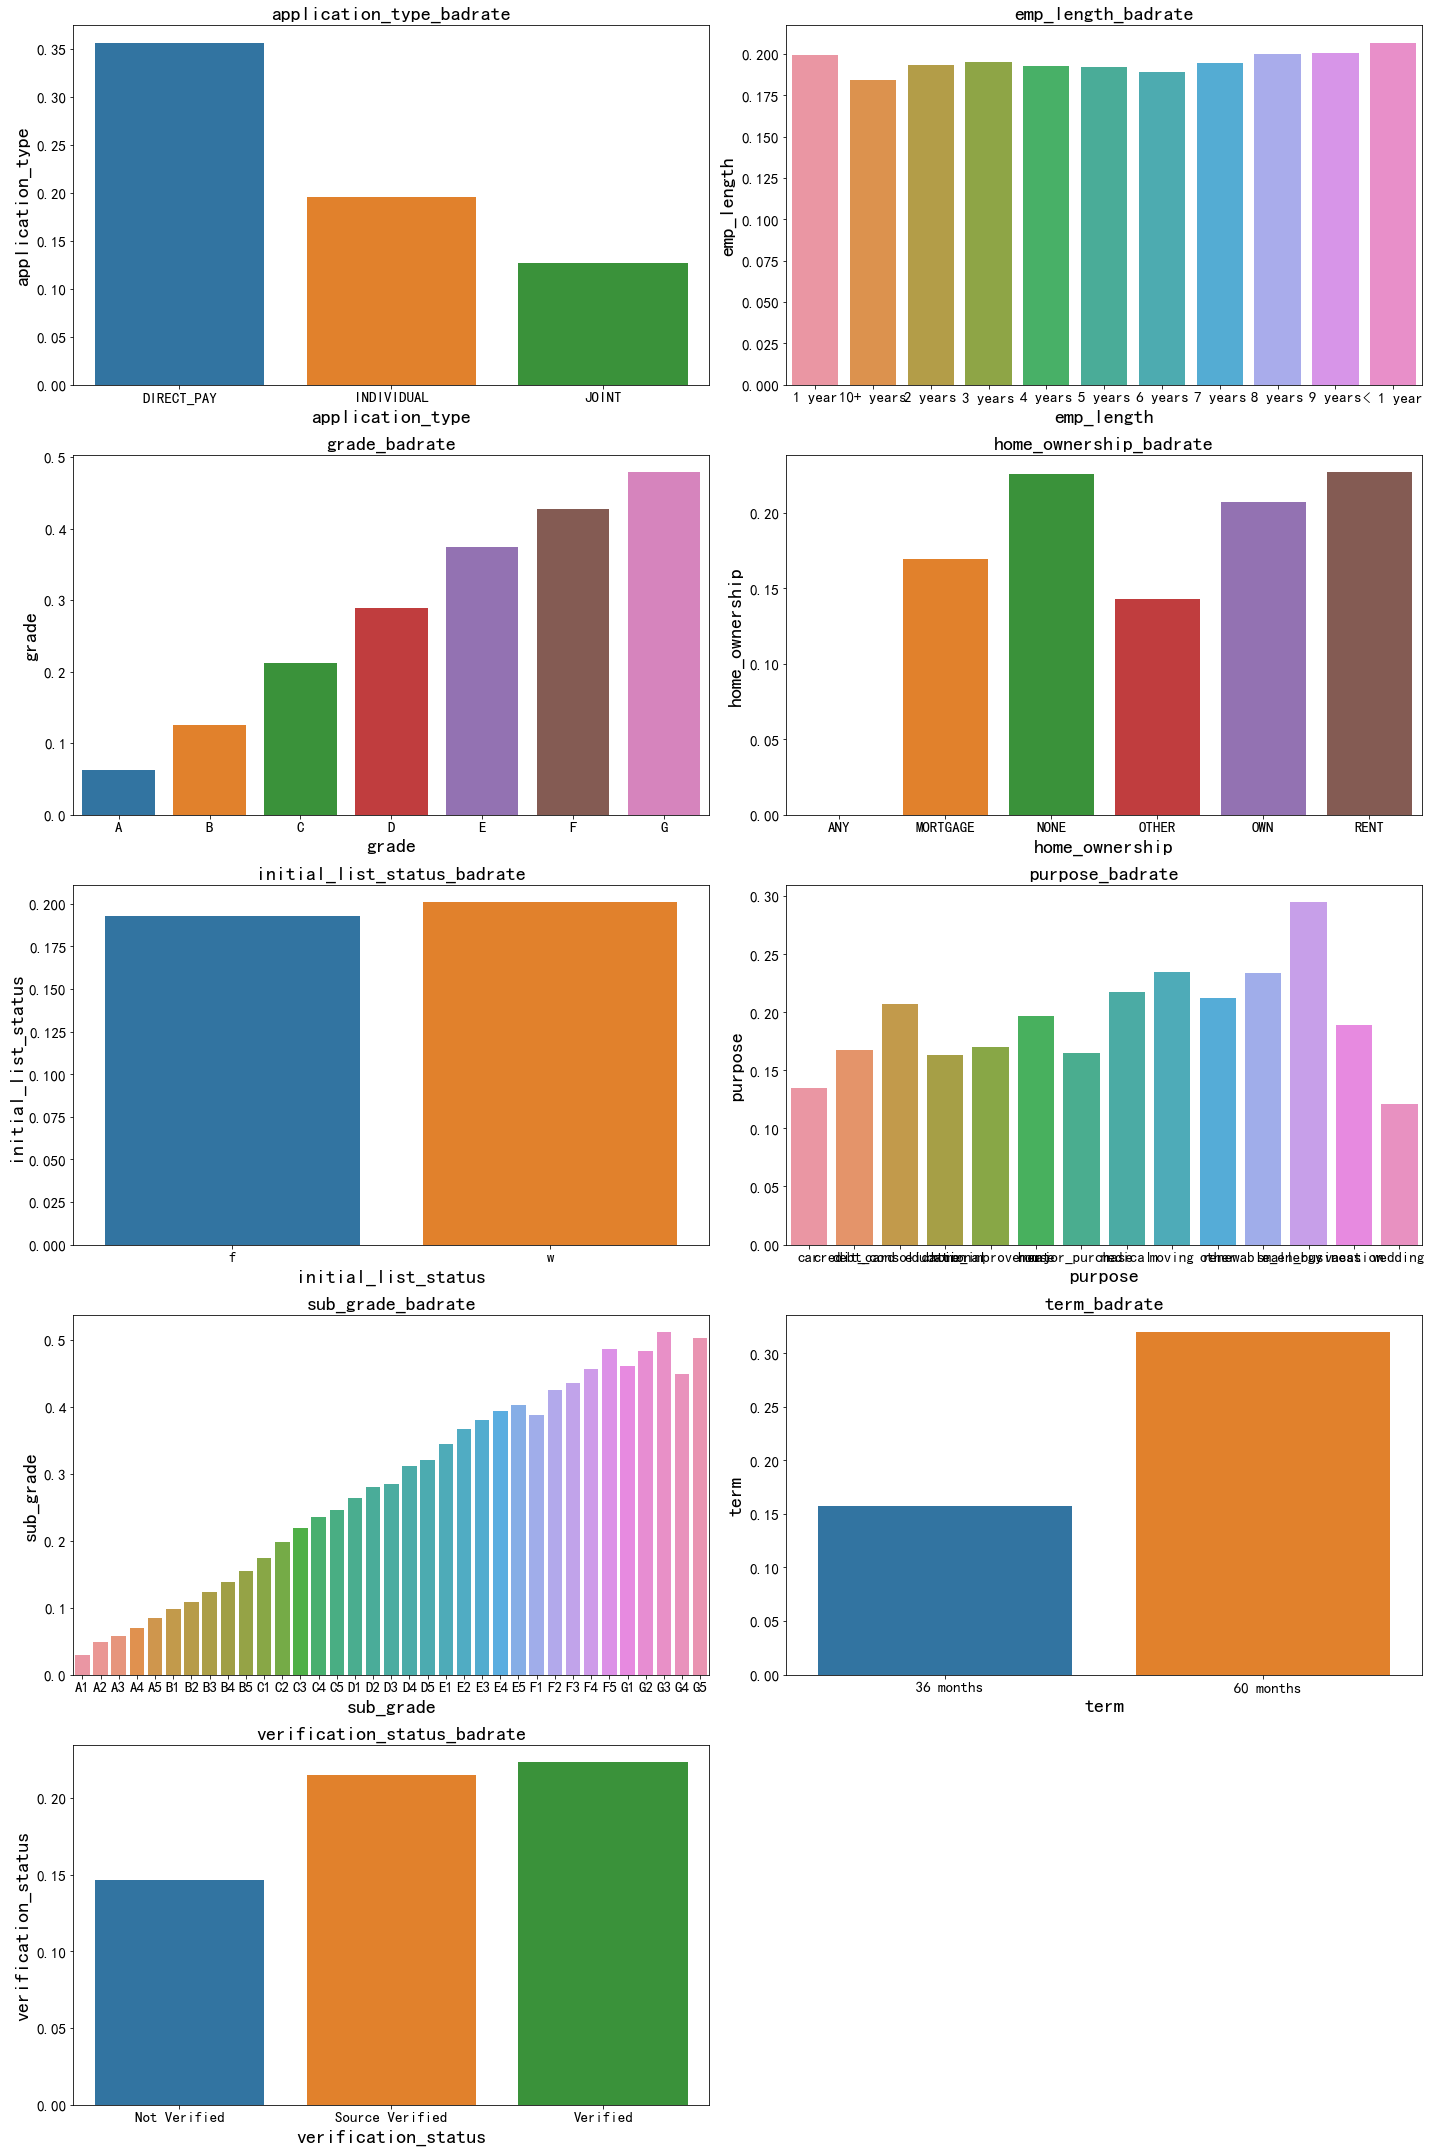

In [131]:
plt.figure(figsize=(20,30))
for i,c in enumerate(obj_list):
    plt.subplot(5, 2, i+1)
    tp = df.groupby([c],as_index=False)[yflag].agg(['mean'])
    sns.barplot(x=c,y='mean',data=tp)
    plt.xticks(size = 15) # 刻度
    plt.yticks(size = 15)
    plt.xlabel(c, fontdict={'size':20}, labelpad=5) #labelpad为标题距离刻度线范围
    plt.ylabel(c, fontdict={'size':20}, labelpad=5)
    plt.title(c+'_badrate', size=20)
    plt.tight_layout()

### 2.3. 连续型变量IV计算

In [132]:
def cal_iv(df0, var_iv, y_flag, breaks_list, stop_limit0):
    """
    分箱并计算IV值
    :param df0: DF格式的数据
    :param var_iv: 需要计算iv的列的列表
    :param y_flag: y标签
    :return iv_df: variable和iv值
    :return bins_base: 字典，分箱值
    """
    iv_list = []
    bins_base = sc.woebin(df0[var_iv + [y_flag]], y=y_flag, breaks_list=breaks_list, method='tree', stop_limit=stop_limit0)
    # 分箱可视化图
    bins_show = sc.woebin_plot(bins_base)
    for col, iv_df_i in bins_base.items():
        iv_df_i['bad_distr'] = iv_df_i['bad']/iv_df_i['bad'].sum() #边际坏占比
        iv_df_i['good_distr'] = iv_df_i['good']/iv_df_i['good'].sum() #边际好占比
        iv_df_i = iv_df_i.rename(columns={'variable':'变量名','bin':'分箱','count':'分箱客户数','count_distr':'分箱客户数占比',
                                         'good':'好客户数','bad':'坏客户数','badprob':'区间坏账率','bad_distr':'边际坏客户占比',
                                         'good_distr':'边际好客户占比'})
        iv_df_i = iv_df_i[['变量名','分箱','分箱客户数','好客户数','坏客户数','分箱客户数占比','边际好客户占比','边际坏客户占比',
                           '区间坏账率','woe','bin_iv','total_iv']]
        bins_base[col] = iv_df_i
        iv_list.append((col,iv_df_i['total_iv'][0])) 
    iv_df = pd.DataFrame.from_records(iv_list,columns=['variable','iv_train'])
    iv_df = iv_df.sort_values(by=['iv_train'], ascending=False)
    return iv_df, bins_base

该函数返回两个对象：
- `iv_df`是所有变量对应IV值的dataframe；
- `bins_base`是所有变量的分箱结果；

[INFO] creating woe binning ...
Binning on 396030 rows and 13 columns in 00:00:42


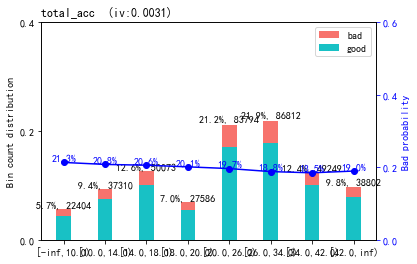

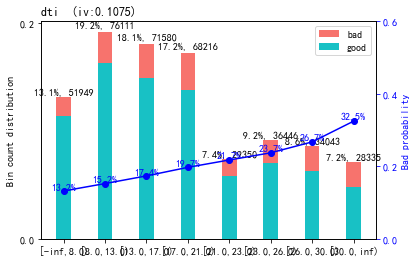

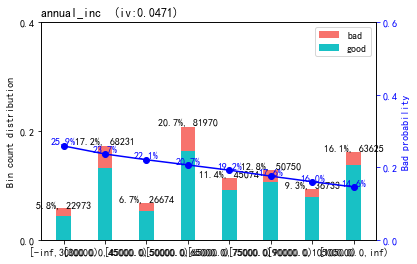

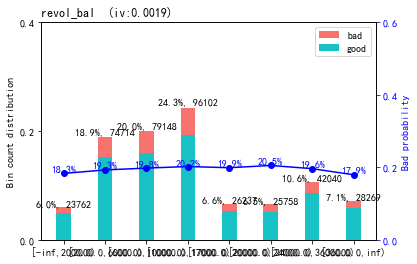

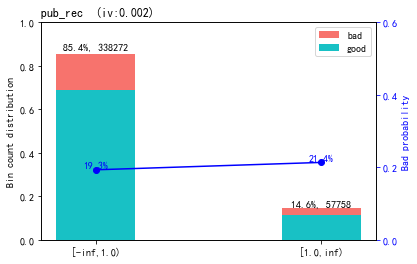

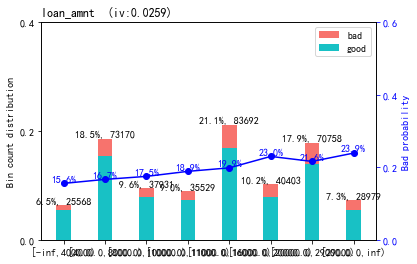

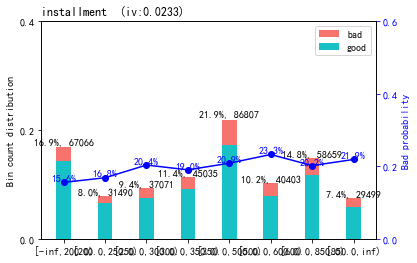

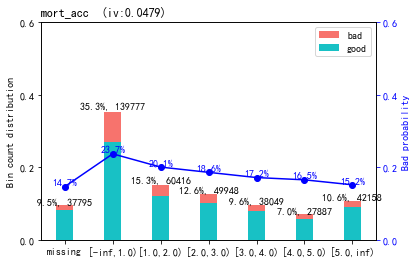

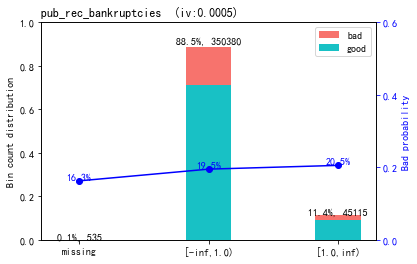

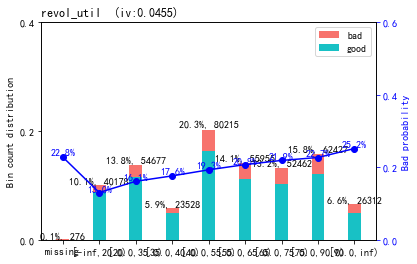

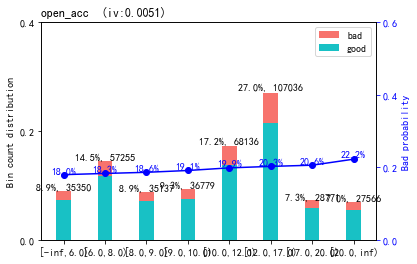

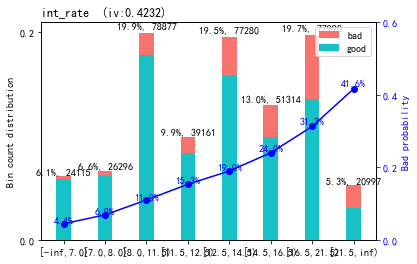

In [133]:
# 计算iv
iv_table, bins_df = cal_iv(df, num_list, y_flag='loan_status', breaks_list={}, stop_limit0=0)

IV指标的一般评判标准：
- `iv < 0.1`: 较弱
- `0.1 <= iv < 0.3`: 强
- `iv > 0.3`: 非常强

In [134]:
iv_table

,variable,iv_train
11,int_rate,0.423240
1,dti,0.107539
7,mort_acc,0.047920
2,annual_inc,0.047112
9,revol_util,0.045488
5,loan_amnt,0.025882
6,installment,0.023303
10,open_acc,0.005051
0,total_acc,0.003104
4,pub_rec,0.002029


- 筛选IV大于0.1的变量

In [135]:
iv_table[iv_table['iv_train']>0.1]

,variable,iv_train
11,int_rate,0.423240
1,dti,0.107539


- 查看变量分箱

In [138]:
bins_df['dti']

,变量名,分箱,分箱客户数,好客户数,坏客户数,分箱客户数占比,边际好客户占比,边际坏客户占比,区间坏账率,woe,bin_iv,total_iv
0,dti,"[-inf,8.0)",51949,45089,6860,0.131174,0.141630,0.088319,0.132053,-0.472265,0.025177,0.107539
1,dti,"[8.0,13.0)",76111,64507,11604,0.192185,0.202625,0.149396,0.152462,-0.304758,0.016222,0.107539
2,dti,"[13.0,17.0)",71580,59154,12426,0.180744,0.185810,0.159978,0.173596,-0.149687,0.003867,0.107539
3,dti,"[17.0,21.0)",68216,54762,13454,0.172250,0.172014,0.173213,0.197226,0.006946,0.000008,0.107539
4,dti,"[21.0,23.0)",29350,22967,6383,0.074111,0.072142,0.082178,0.217479,0.130245,0.001307,0.107539
5,dti,"[23.0,26.0)",36446,27797,8649,0.092028,0.087314,0.111351,0.237310,0.243181,0.005845,0.107539
6,dti,"[26.0,30.0)",34043,24941,9102,0.085961,0.078343,0.117184,0.267368,0.402647,0.015639,0.107539
7,dti,"[30.0,inf)",28335,19140,9195,0.071548,0.060121,0.118381,0.324510,0.677545,0.039474,0.107539


In [137]:
# 整体样本坏客户浓度
df[yflag].mean()

0.1961290811302174

以上分箱我们观察到：
- badprob(区间坏账率)有明显排序性，`int_rate(利率)`和`dti(负债比)`随着数值增大区间坏账率单调递增；
- 符合业务可解释性，`int_rate(利率)`和`dti(负债比)`值越大，客户风险越高；

# 交叉表规则生成

基于二维交叉表分析生成组合规则的 Python 实现，包含数据探索、变量分箱、透视表构建与规则制定。

## 1. 连续型变量分箱

In [139]:
df['int_rate_bins'] = pd.cut(df['int_rate'],bins=[-1,7,8,11.5,12.5,14.5,16.5,21.5,100])
df['dti_bins'] = pd.cut(df['dti'],bins=[-1,8,13,17,21,23,26,30,1000])

## 2. 透视表

### 2.1. 格子客户计数

In [140]:
loan_cnt = pd.crosstab(df['int_rate_bins'], df['grade'])
loan_cnt

grade,A,B,C,D,E,F,G
int_rate_bins,,,,,,,
"(-1.0, 7.0]",24047,24,16,12,13,2,1
"(7.0, 8.0]",26453,0,0,0,0,0,0
"(8.0, 11.5]",13687,64881,152,0,0,0,0
"(11.5, 12.5]",0,31149,7985,27,0,0,0
"(12.5, 14.5]",0,19964,56866,431,25,0,0
"(14.5, 16.5]",0,0,35808,14999,483,18,0
"(16.5, 21.5]",0,0,5160,48055,23864,770,141
"(21.5, 100.0]",0,0,0,0,7103,10982,2912


### 2.2. 格子坏客户数求和

In [141]:
loan_bad_sum = df.pivot_table(index='int_rate_bins',columns='grade',values=yflag, aggfunc='sum')
loan_bad_sum

grade,A,B,C,D,E,F,G
int_rate_bins,,,,,,,
"(-1.0, 7.0]",1065,0,0,1,1,0,0
"(7.0, 8.0]",1819,0,0,0,0,0,0
"(8.0, 11.5]",1152,7487,30,0,0,0,0
"(11.5, 12.5]",0,4397,1593,10,0,0,0
"(12.5, 14.5]",0,2703,11879,83,7,0,0
"(14.5, 16.5]",0,0,7792,4411,109,7,0
"(16.5, 21.5]",0,0,1155,13833,9123,231,44
"(21.5, 100.0]",0,0,0,0,2525,4799,1417


### 2.3. 区间坏账率

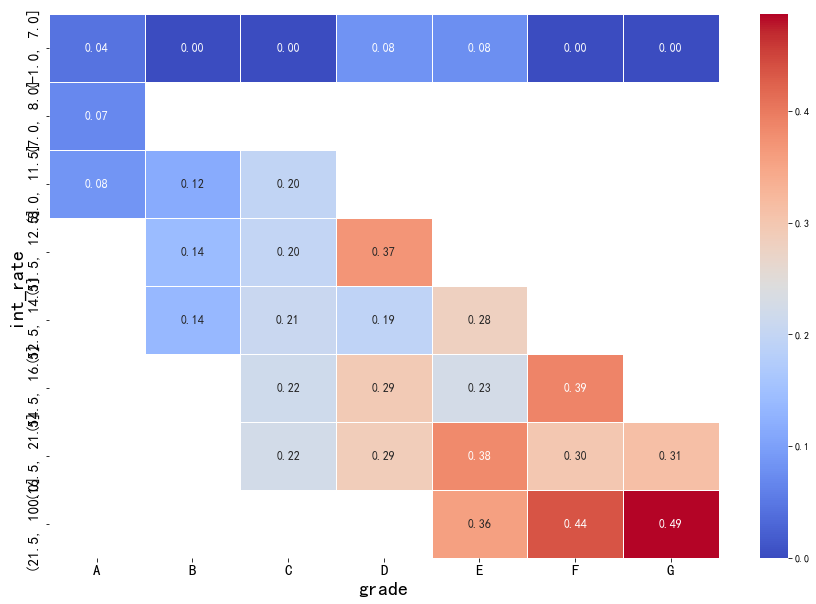

In [142]:
# 区间坏账率
cross_badrate = loan_bad_sum/loan_cnt
# 可视化
plt.figure(figsize=(15,10))
sns.heatmap(cross_badrate, cmap='coolwarm', annot=True, fmt='.2f', linewidths=.5, annot_kws={'size':12}) 
plt.xticks(size = 15) # 刻度
plt.yticks(size = 15)
plt.xlabel('grade', fontdict={'size':20}, labelpad=5) #labelpad为标题距离刻度线范围
plt.ylabel('int_rate', fontdict={'size':20}, labelpad=5)
plt.show()

### 2.4. 客户数占比

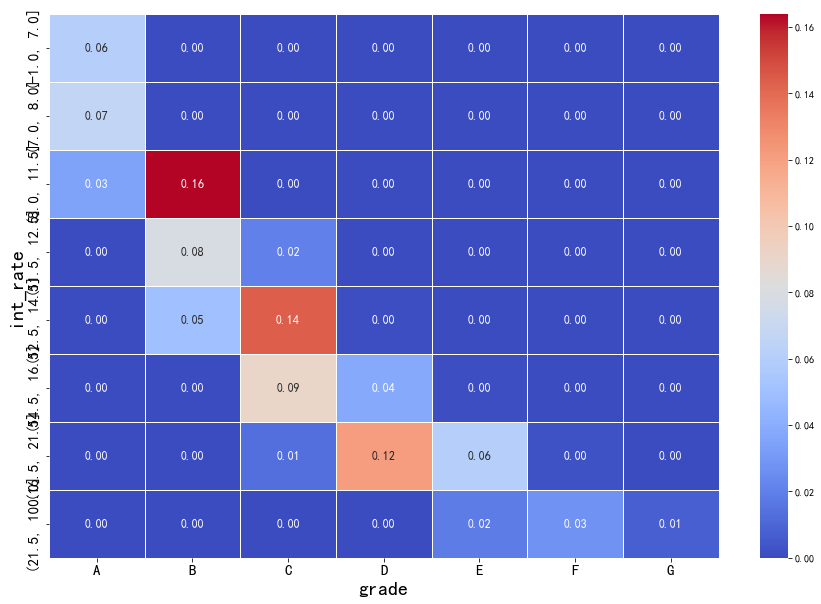

In [143]:
loan_pct = loan_cnt/df.shape[0]
# 可视化
plt.figure(figsize=(15,10))
sns.heatmap(loan_pct, cmap='coolwarm', annot=True, fmt='.2f', linewidths=.5, annot_kws={'size':12}) 
plt.xticks(size = 15) # 刻度
plt.yticks(size = 15)
plt.xlabel('grade', fontdict={'size':20}, labelpad=5) #labelpad为标题距离刻度线范围
plt.ylabel('int_rate', fontdict={'size':20}, labelpad=5)
plt.show()

## 3. 制定规则

**规则：(int_rate>21.5)&(grade==G)**

评估指标：
- badrate=49%
- lift=49%/19.61%=2.5
- hitrate=1%

**规则：(int_rate>21.5)&(grade==G|F)**

评估指标：
- badrate=44.74%
- lift=44.74%/19.61%=2.3
- hitrate=4%

# 交叉表规则生成

基于二维交叉表分析生成组合规则的 Python 实现，包含数据探索、变量分箱、透视表构建与规则制定。

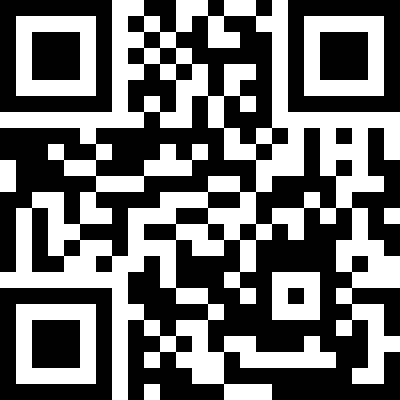